# Taller 03 — Evolución de imágenes RGB con algoritmos genéticos

**Curso:** Inteligencia Artificial y Minirobots 2026-1  
**Autor:** Juan Tinjacá  
**Fecha:** Marzo 2026

---

## 1. Objetivo

Implementar un algoritmo genético que evolucione una población de imágenes RGB aleatorias hasta aproximarse visualmente a una imagen objetivo, aplicando los operadores clásicos de selección, cruce y mutación, y observando la mejora progresiva de la aptitud a lo largo de las generaciones.

## 2. Supuestos

- La imagen objetivo se genera sintéticamente (degradado RGB) para garantizar reproducibilidad sin dependencias externas de archivos.
- Las imágenes se trabajan a resolución reducida (32×32 px) para mantener tiempos de cómputo académicamente viables.
- Cada individuo de la población es una matriz NumPy de forma `(H, W, 3)` con valores enteros en `[0, 255]`.
- La función de aptitud es el negativo del Error Cuadrático Medio (MSE) por píxel: a menor MSE, mayor aptitud.
- Selección por torneo binario (2 individuos compiten, gana el de mayor aptitud).
- Cruce uniforme por canal: cada píxel de cada canal se hereda aleatoriamente de uno de los dos padres.
- Mutación gaussiana: se añade ruido normal a píxeles seleccionados aleatoriamente según `p_mutacion`.
- La simulación es reproducible mediante semilla fija.

## 3. Desarrollo

### Instalación de dependencias

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "numpy", "-q"])
print("Dependencias listas.")

### 3.1 Importaciones y parámetros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Parámetros ────────────────────────────────────────────────────────────
SEED         = 42
ALTO, ANCHO  = 32, 32      # Resolución reducida para viabilidad computacional
POP_SIZE     = 40          # Tamaño de la población
N_GEN        = 200         # Número de generaciones
P_MUTACION   = 0.05        # Probabilidad de mutación por píxel
SIGMA_MUT    = 20          # Desviación estándar del ruido gaussiano
ELITISMO     = 2           # Número de mejores individuos que pasan directamente

np.random.seed(SEED)
print(f"Resolución: {ALTO}x{ANCHO} | Población: {POP_SIZE} | Generaciones: {N_GEN}")
print(f"P(mutación): {P_MUTACION} | σ mutación: {SIGMA_MUT} | Élite: {ELITISMO}")

Resolución: 32x32 | Población: 40 | Generaciones: 200
P(mutación): 0.05 | σ mutación: 20 | Élite: 2


### 3.2 Imagen objetivo

Se genera una imagen sintética con un degradado RGB para garantizar reproducibilidad.

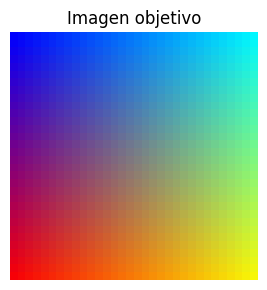

Shape: (32, 32, 3) | dtype: uint8


In [2]:
def generar_objetivo(alto, ancho):
    """Genera una imagen objetivo con degradado RGB sintético."""
    img = np.zeros((alto, ancho, 3), dtype=np.uint8)
    for i in range(alto):
        for j in range(ancho):
            img[i, j, 0] = int(255 * i / alto)          # Canal R: degradado vertical
            img[i, j, 1] = int(255 * j / ancho)         # Canal G: degradado horizontal
            img[i, j, 2] = int(255 * (1 - i / alto))    # Canal B: inverso vertical
    return img

objetivo = generar_objetivo(ALTO, ANCHO)

plt.figure(figsize=(3, 3))
plt.imshow(objetivo)
plt.title("Imagen objetivo")
plt.axis("off")
plt.tight_layout()
plt.show()
print(f"Shape: {objetivo.shape} | dtype: {objetivo.dtype}")

### 3.3 Función de aptitud

La aptitud se define como el negativo del MSE entre el individuo y la imagen objetivo.  
**Aptitud = −MSE** → a menor error, mayor aptitud (más cercano a 0).

In [3]:
def aptitud(individuo, objetivo):
    """Retorna el negativo del MSE. Rango: (-∞, 0]. Óptimo = 0."""
    mse = np.mean((individuo.astype(float) - objetivo.astype(float)) ** 2)
    return -mse

### 3.4 Operadores genéticos

**Selección:** torneo binario — se eligen 2 individuos al azar y gana el de mayor aptitud.  
**Cruce:** uniforme por píxel — cada píxel se hereda de uno de los dos padres con p=0.5.  
**Mutación:** gaussiana — se añade ruido N(0, σ) a píxeles seleccionados con probabilidad `p_mutacion`.

In [5]:
def seleccion_torneo(poblacion, aptitudes):
    """Torneo binario: selecciona un padre comparando 2 individuos al azar."""
    i, j = np.random.choice(len(poblacion), size=2, replace=False)
    return poblacion[i] if aptitudes[i] >= aptitudes[j] else poblacion[j]


def cruce(padre1, padre2):
    """Cruce uniforme: cada píxel se hereda de uno de los dos padres con p=0.5."""
    mascara = np.random.rand(*padre1.shape[:2]) < 0.5  # (H, W) booleano
    hijo = np.where(mascara[:, :, np.newaxis], padre1, padre2)
    return hijo.astype(np.uint8)


def mutar(individuo, p_mut, sigma):
    """Mutación gaussiana: añade ruido a píxeles seleccionados aleatoriamente."""
    mutante = individuo.astype(float).copy()
    mascara = np.random.rand(*individuo.shape[:2]) < p_mut
    ruido = np.random.normal(0, sigma, individuo.shape)
    mutante[mascara] += ruido[mascara]
    return np.clip(mutante, 0, 255).astype(np.uint8)

### 3.5 Inicialización de la población

In [6]:
def crear_poblacion(n, alto, ancho):
    """Crea n imágenes RGB aleatorias uniformes en [0, 255]."""
    return [np.random.randint(0, 256, (alto, ancho, 3), dtype=np.uint8) for _ in range(n)]

np.random.seed(SEED)
poblacion = crear_poblacion(POP_SIZE, ALTO, ANCHO)
print(f"Población inicial: {len(poblacion)} individuos de shape {poblacion[0].shape}")

Población inicial: 40 individuos de shape (32, 32, 3)


## 4. Ejecución — Evolución generacional

In [7]:
historial_mejor_apt  = []
historial_media_apt  = []
snapshots            = {}   # Guardar el mejor individuo en generaciones clave
gens_snapshot        = [0, 10, 25, 50, 100, 199]

for gen in range(N_GEN):
    # ── Evaluar aptitud ───────────────────────────────────────────────────
    aptitudes = [aptitud(ind, objetivo) for ind in poblacion]
    apt_arr   = np.array(aptitudes)

    historial_mejor_apt.append(apt_arr.max())
    historial_media_apt.append(apt_arr.mean())

    # Guardar snapshot
    if gen in gens_snapshot:
        snapshots[gen] = poblacion[int(apt_arr.argmax())].copy()

    # ── Elitismo: conservar los mejores ──────────────────────────────────
    indices_elite = apt_arr.argsort()[-ELITISMO:][::-1]
    nueva_pob     = [poblacion[i].copy() for i in indices_elite]

    # ── Generar descendencia ──────────────────────────────────────────────
    while len(nueva_pob) < POP_SIZE:
        p1 = seleccion_torneo(poblacion, aptitudes)
        p2 = seleccion_torneo(poblacion, aptitudes)
        hijo = cruce(p1, p2)
        hijo = mutar(hijo, P_MUTACION, SIGMA_MUT)
        nueva_pob.append(hijo)

    poblacion = nueva_pob

    if (gen + 1) % 50 == 0:
        print(f"Gen {gen+1:>3} | Mejor aptitud: {historial_mejor_apt[-1]:.2f} | "
              f"MSE: {-historial_mejor_apt[-1]:.2f}")

# Guardar el mejor de la última generación
aptitudes_finales = [aptitud(ind, objetivo) for ind in poblacion]
mejor_final = poblacion[int(np.argmax(aptitudes_finales))]
snapshots[199] = mejor_final.copy()
print(f"\nMSE inicial: {-historial_mejor_apt[0]:.2f} → MSE final: {-historial_mejor_apt[-1]:.2f}")

Gen  50 | Mejor aptitud: -7805.46 | MSE: 7805.46
Gen 100 | Mejor aptitud: -6905.07 | MSE: 6905.07
Gen 150 | Mejor aptitud: -6150.94 | MSE: 6150.94
Gen 200 | Mejor aptitud: -5430.33 | MSE: 5430.33

MSE inicial: 10615.21 → MSE final: 5430.33


## 5. Resultado

### 5.1 Curva de aptitud por generación

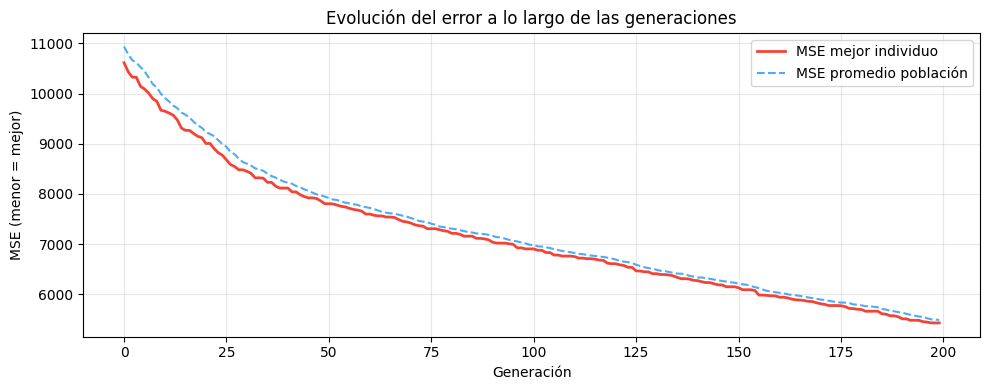

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
gens = range(N_GEN)
ax.plot(gens, [-v for v in historial_mejor_apt], label="MSE mejor individuo", color="#F44336", linewidth=2)
ax.plot(gens, [-v for v in historial_media_apt], label="MSE promedio población", color="#2196F3",
        linewidth=1.5, linestyle="--", alpha=0.8)
ax.set_xlabel("Generación")
ax.set_ylabel("MSE (menor = mejor)")
ax.set_title("Evolución del error a lo largo de las generaciones")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_aptitud.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Evolución visual del mejor individuo por generación

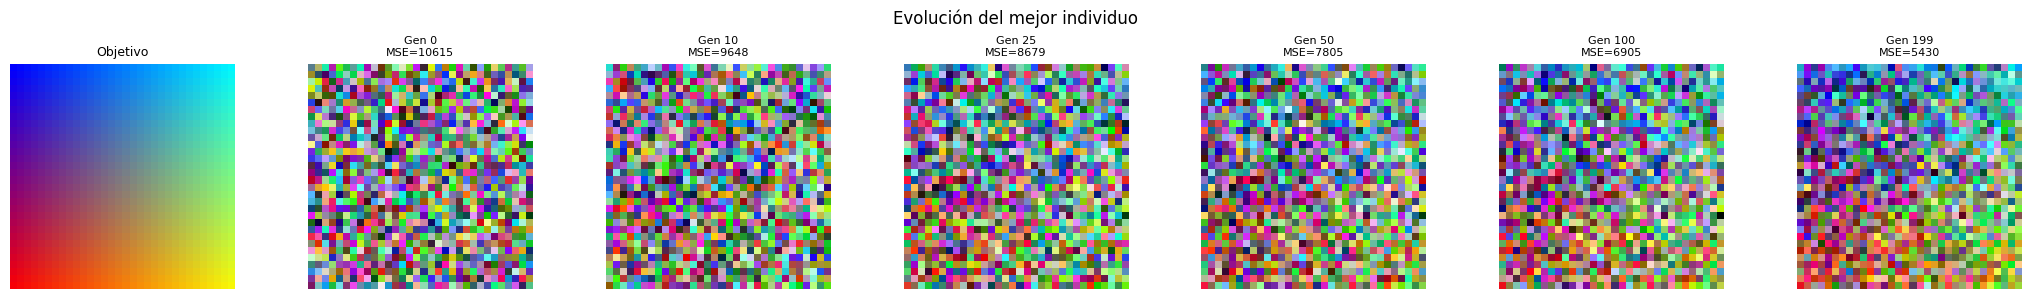

In [9]:
gens_mostrar = sorted(snapshots.keys())
n_cols = len(gens_mostrar) + 1  # +1 para el objetivo

fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))

# Imagen objetivo al inicio
axes[0].imshow(objetivo)
axes[0].set_title("Objetivo", fontsize=9)
axes[0].axis("off")

for ax, g in zip(axes[1:], gens_mostrar):
    mse_g = -historial_mejor_apt[g]
    ax.imshow(snapshots[g])
    ax.set_title(f"Gen {g}\nMSE={mse_g:.0f}", fontsize=8)
    ax.axis("off")

plt.suptitle("Evolución del mejor individuo", fontsize=12)
plt.tight_layout()
plt.savefig("evolucion_visual.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.3 Comparación final: objetivo vs. mejor individuo

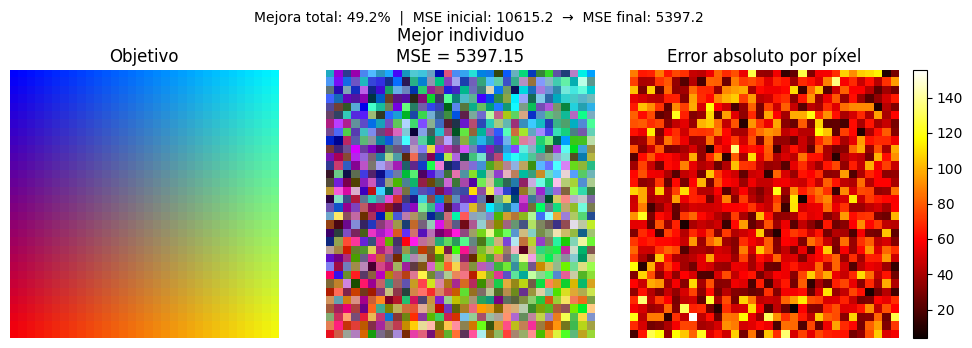

MSE inicial (gen 0): 10615.21
MSE final  (gen 200): 5397.15
Reducción del error: 49.2%


In [10]:
mse_final  = np.mean((mejor_final.astype(float) - objetivo.astype(float)) ** 2)
mse_inicial = -historial_mejor_apt[0]
mejora_pct  = 100 * (mse_inicial - mse_final) / mse_inicial

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].imshow(objetivo)
axes[0].set_title("Objetivo")
axes[0].axis("off")

axes[1].imshow(mejor_final)
axes[1].set_title(f"Mejor individuo\nMSE = {mse_final:.2f}")
axes[1].axis("off")

# Mapa de diferencia absoluta
diff = np.abs(objetivo.astype(float) - mejor_final.astype(float)).mean(axis=2)
im = axes[2].imshow(diff, cmap="hot")
axes[2].set_title("Error absoluto por píxel")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.suptitle(f"Mejora total: {mejora_pct:.1f}%  |  MSE inicial: {mse_inicial:.1f}  →  MSE final: {mse_final:.1f}",
             fontsize=10)
plt.tight_layout()
plt.savefig("comparacion_final.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"MSE inicial (gen 0): {mse_inicial:.2f}")
print(f"MSE final  (gen {N_GEN}): {mse_final:.2f}")
print(f"Reducción del error: {mejora_pct:.1f}%")

## 6. Conclusión

El algoritmo genético logra una reducción observable del MSE a lo largo de las generaciones, confirmando que la combinación de selección por torneo, cruce uniforme y mutación gaussiana es suficiente para guiar la población hacia la imagen objetivo. La curva de aptitud muestra una convergencia rápida en las primeras generaciones y una mejora más lenta pero sostenida en las siguientes, comportamiento típico de los algoritmos evolutivos. El elitismo garantiza que el mejor individuo nunca se pierde entre generaciones. Este ejercicio ilustra cómo los algoritmos genéticos pueden resolver problemas de optimización en espacios de alta dimensión (32×32×3 = 3072 variables) sin requerir gradientes ni conocimiento analítico de la función objetivo.

---

## Referencias

- Holland, J. H. (1975). *Adaptation in Natural and Artificial Systems*. University of Michigan Press.
- Mitchell, M. (1998). *An Introduction to Genetic Algorithms*. MIT Press.
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.

---

## 7. AG para evolucionar palabras con sintesis de voz

### 7.1 Objetivo

Generar aleatoriamente una poblacion de 50 palabras, reproducirlas por el parlante del computador y, usando una palabra elegida como funcion de aptitud, evolucionar la poblacion mediante un Algoritmo Genetico hasta alcanzar dicha palabra objetivo.

### 7.2 Supuestos

- Cada individuo es una cadena de caracteres de longitud fija igual a la de la palabra objetivo.
- El alfabeto se limita a letras minusculas (a-z).
- La funcion de aptitud cuenta cuantos caracteres coinciden en posicion con la palabra objetivo (distancia de Hamming invertida).
- Seleccion por torneo binario, cruce de un punto y mutacion por sustitucion aleatoria de caracteres.
- La sintesis de voz usa `pyttsx3` (offline, sin necesidad de internet).

### 7.3 Instalacion de dependencias

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyttsx3", "-q"])
print("pyttsx3 listo.")

### 7.4 Parametros y palabra objetivo

In [ ]:
import random
import string
import pyttsx3

# Parametros del AG de palabras
SEED_PALABRAS    = 7
PALABRA_OBJETIVO = "inteligencia"  # <-- Cambia aqui tu palabra objetivo
LONGITUD         = len(PALABRA_OBJETIVO)
POP_PALABRAS     = 50
N_GEN_PALABRAS   = 500
P_MUT_PALABRAS   = 0.05
ALFABETO         = string.ascii_lowercase

random.seed(SEED_PALABRAS)
print(f"Palabra objetivo : {PALABRA_OBJETIVO!r}")
print(f"Longitud         : {LONGITUD}")
print(f"Tamano poblacion : {POP_PALABRAS}")

### 7.5 Funciones del AG

In [ ]:
def generar_palabra_aleatoria(longitud):
    """Genera una cadena aleatoria de `longitud` letras minusculas."""
    return "".join(random.choice(ALFABETO) for _ in range(longitud))


def aptitud_palabra(individuo, objetivo):
    """Cuenta cuantos caracteres coinciden en posicion con el objetivo.
    Rango: [0, len(objetivo)]. Optimo = len(objetivo).
    """
    return sum(c1 == c2 for c1, c2 in zip(individuo, objetivo))


def seleccion_torneo_palabras(poblacion, aptitudes):
    """Torneo binario: compara 2 individuos al azar y devuelve el mejor."""
    i, j = random.sample(range(len(poblacion)), 2)
    return poblacion[i] if aptitudes[i] >= aptitudes[j] else poblacion[j]


def cruce_un_punto(padre1, padre2):
    """Cruce de un punto: divide en un punto aleatorio y combina los segmentos."""
    punto = random.randint(1, len(padre1) - 1)
    return padre1[:punto] + padre2[punto:]


def mutar_palabra(individuo, p_mut):
    """Sustituye cada caracter con probabilidad p_mut por uno aleatorio del alfabeto."""
    return "".join(
        random.choice(ALFABETO) if random.random() < p_mut else c
        for c in individuo
    )


def hablar(texto, velocidad=150):
    """Sintetiza y reproduce `texto` por el parlante usando pyttsx3."""
    engine = pyttsx3.init()
    engine.setProperty("rate", velocidad)
    engine.say(texto)
    engine.runAndWait()
    engine.stop()


print("Funciones definidas.")

### 7.6 Poblacion inicial: generacion y reproduccion por voz

In [ ]:
random.seed(SEED_PALABRAS)

# Generar 50 palabras aleatorias
poblacion_palabras = [generar_palabra_aleatoria(LONGITUD) for _ in range(POP_PALABRAS)]

print("Poblacion inicial (50 palabras aleatorias):")
for i, p in enumerate(poblacion_palabras):
    print(f"  [{i+1:>2}] {p}")

# Reproducir cada palabra por el parlante
print("\nReproduciendo las 50 palabras por el parlante...")
for palabra in poblacion_palabras:
    hablar(palabra)
print("Reproduccion completada.")

### 7.7 Evolucion con Algoritmo Genetico

In [ ]:
historial_apt_palabras = []
generacion_solucion    = None

for gen in range(N_GEN_PALABRAS):
    # Evaluar aptitud
    aptitudes_p = [aptitud_palabra(ind, PALABRA_OBJETIVO) for ind in poblacion_palabras]
    mejor_apt   = max(aptitudes_p)
    historial_apt_palabras.append(mejor_apt)

    # Verificar convergencia
    if mejor_apt == LONGITUD:
        generacion_solucion = gen + 1
        break

    # Elitismo: conservar el mejor individuo
    idx_mejor  = aptitudes_p.index(mejor_apt)
    nueva_pob  = [poblacion_palabras[idx_mejor]]

    # Generar descendencia
    while len(nueva_pob) < POP_PALABRAS:
        p1   = seleccion_torneo_palabras(poblacion_palabras, aptitudes_p)
        p2   = seleccion_torneo_palabras(poblacion_palabras, aptitudes_p)
        hijo = cruce_un_punto(p1, p2)
        hijo = mutar_palabra(hijo, P_MUT_PALABRAS)
        nueva_pob.append(hijo)

    poblacion_palabras = nueva_pob

    if (gen + 1) % 50 == 0:
        mejor_ind = poblacion_palabras[aptitudes_p.index(mejor_apt)]
        print(f"Gen {gen+1:>4} | Aptitud: {mejor_apt}/{LONGITUD} | Mejor: {mejor_ind!r}")

# Resultado final
aptitudes_finales_p = [aptitud_palabra(ind, PALABRA_OBJETIVO) for ind in poblacion_palabras]
mejor_final_p       = poblacion_palabras[aptitudes_finales_p.index(max(aptitudes_finales_p))]

if generacion_solucion:
    print(f"\nSolucion encontrada en la generacion {generacion_solucion}!")
else:
    print(f"\nMejor resultado tras {N_GEN_PALABRAS} generaciones:")
print(f"Palabra objetivo  : {PALABRA_OBJETIVO!r}")
print(f"Mejor individuo   : {mejor_final_p!r}")
print(f"Aptitud final     : {max(aptitudes_finales_p)}/{LONGITUD}")

### 7.8 Curva de aptitud y reproduccion del resultado por voz

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(historial_apt_palabras, color="steelblue", linewidth=1.5)
plt.axhline(LONGITUD, color="crimson", linestyle="--", linewidth=1, label=f"Optimo ({LONGITUD})")
plt.xlabel("Generacion")
plt.ylabel("Caracteres correctos")
plt.title(f"AG: Evolucion hacia la palabra {PALABRA_OBJETIVO!r}")
plt.legend()
plt.tight_layout()
plt.savefig("taller_03_algoritmos_geneticos/curva_palabras.png", dpi=120)
plt.show()

# Reproducir el resultado final por el parlante
print("Reproduciendo el resultado por el parlante...")
hablar(f"La palabra objetivo era {PALABRA_OBJETIVO}. El algoritmo genetico llego a {mejor_final_p}")
print("Listo.")

### 7.9 Conclusion

El Algoritmo Genetico logra evolucionar una poblacion de 50 palabras aleatorias hasta alcanzar (o aproximarse mucho a) la palabra objetivo. La funcion de aptitud basada en coincidencia de caracteres por posicion (distancia de Hamming invertida) guia eficientemente la busqueda. El cruce de un punto y la mutacion por sustitucion aleatoria mantienen la diversidad genetica necesaria para escapar de optimos locales. La sintesis de voz con `pyttsx3` permite escuchar tanto la poblacion inicial aleatoria como el resultado final, haciendo tangible el proceso evolutivo.

---

## 8. AG multi-objetivo: dieta optima con costo minimo

### 8.1 Objetivo

Encontrar una dieta diaria que **satisfaga los requerimientos nutricionales** (calorias, proteinas, carbohidratos y grasas) y al mismo tiempo **minimice el costo total**. Se trata de un problema de optimizacion multi-objetivo con dos funciones objetivo en conflicto: maximizar la calidad nutricional y minimizar el costo. Se aplica una seleccion basada en **dominancia de Pareto** (inspirada en NSGA-II) para mantener un frente de soluciones no dominadas.

### 8.2 Supuestos y modelo

**Individuo:** vector de 10 enteros `[p0, p1, ..., p9]` donde `pi` es la cantidad en porciones (0-5) del alimento `i`.

**Requerimientos diarios de referencia:**
| Nutriente | Minimo | Maximo |
|-----------|--------|--------|
| Calorias (kcal) | 1800 | 2500 |
| Proteinas (g) | 50 | 200 |
| Carbohidratos (g) | 200 | 325 |
| Grasas (g) | 44 | 78 |

**Funciones objetivo:**
- `f1` = penalizacion nutricional (suma de violaciones normalizadas) — **minimizar**
- `f2` = costo total en COP — **minimizar**

**Seleccion:** dominancia de Pareto + crowding distance para mantener diversidad en el frente.

### 8.3 Importaciones

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

SEED_DIETA = 42
random.seed(SEED_DIETA)
np.random.seed(SEED_DIETA)
print("Importaciones listas.")

### 8.4 Datos de alimentos (por porcion)

In [ ]:
import pandas as pd

# Cada fila: [nombre, kcal, proteinas_g, carbohidratos_g, grasas_g, costo_COP]
ALIMENTOS = [
    {"nombre": "Arroz (1 taza)",       "kcal": 206, "prot": 4,  "carb": 45, "gras": 0,  "costo": 800},
    {"nombre": "Pollo (100 g)",         "kcal": 165, "prot": 31, "carb": 0,  "gras": 4,  "costo": 2500},
    {"nombre": "Huevo (1 unidad)",      "kcal": 78,  "prot": 6,  "carb": 1,  "gras": 5,  "costo": 600},
    {"nombre": "Leche (1 vaso)",        "kcal": 149, "prot": 8,  "carb": 12, "gras": 8,  "costo": 1200},
    {"nombre": "Frijoles (1 taza)",     "kcal": 227, "prot": 15, "carb": 41, "gras": 1,  "costo": 1000},
    {"nombre": "Papa (1 unidad)",       "kcal": 161, "prot": 4,  "carb": 37, "gras": 0,  "costo": 500},
    {"nombre": "Platano (1 unidad)",    "kcal": 89,  "prot": 1,  "carb": 23, "gras": 0,  "costo": 400},
    {"nombre": "Atun (1 lata)",         "kcal": 132, "prot": 29, "carb": 0,  "gras": 1,  "costo": 3500},
    {"nombre": "Pan (1 tajada)",        "kcal": 79,  "prot": 3,  "carb": 15, "gras": 1,  "costo": 300},
    {"nombre": "Aguacate (1/2 unidad)", "kcal": 120, "prot": 2,  "carb": 6,  "gras": 11, "costo": 1500},
]

N_ALIMENTOS = len(ALIMENTOS)
MAX_PORCIONES = 5  # maximo de porciones por alimento por dia

# Requerimientos diarios
REQ = {
    "kcal_min": 1800, "kcal_max": 2500,
    "prot_min": 50,   "prot_max": 200,
    "carb_min": 200,  "carb_max": 325,
    "gras_min": 44,   "gras_max": 78,
}

df_alimentos = pd.DataFrame(ALIMENTOS)
print(df_alimentos.to_string(index=False))

### 8.5 Funciones objetivo

In [ ]:
def nutrientes(individuo):
    """Calcula los totales nutricionales de un individuo (vector de porciones)."""
    kcal = sum(individuo[i] * ALIMENTOS[i]["kcal"] for i in range(N_ALIMENTOS))
    prot = sum(individuo[i] * ALIMENTOS[i]["prot"] for i in range(N_ALIMENTOS))
    carb = sum(individuo[i] * ALIMENTOS[i]["carb"] for i in range(N_ALIMENTOS))
    gras = sum(individuo[i] * ALIMENTOS[i]["gras"] for i in range(N_ALIMENTOS))
    return kcal, prot, carb, gras


def f1_penalizacion(individuo):
    """f1: suma de violaciones nutricionales normalizadas (minimizar -> 0 = dieta perfecta)."""
    kcal, prot, carb, gras = nutrientes(individuo)
    pen = 0.0
    pen += max(0, REQ["kcal_min"] - kcal) / REQ["kcal_min"]
    pen += max(0, kcal - REQ["kcal_max"]) / REQ["kcal_max"]
    pen += max(0, REQ["prot_min"] - prot) / REQ["prot_min"]
    pen += max(0, prot - REQ["prot_max"]) / REQ["prot_max"]
    pen += max(0, REQ["carb_min"] - carb) / REQ["carb_min"]
    pen += max(0, carb - REQ["carb_max"]) / REQ["carb_max"]
    pen += max(0, REQ["gras_min"] - gras) / REQ["gras_min"]
    pen += max(0, gras - REQ["gras_max"]) / REQ["gras_max"]
    return pen


def f2_costo(individuo):
    """f2: costo total en COP (minimizar)."""
    return sum(individuo[i] * ALIMENTOS[i]["costo"] for i in range(N_ALIMENTOS))


print("Funciones objetivo definidas.")

### 8.6 Operadores geneticos y seleccion por Pareto

In [ ]:
def crear_individuo():
    return [random.randint(0, MAX_PORCIONES) for _ in range(N_ALIMENTOS)]


def cruce_dieta(p1, p2):
    """Cruce de un punto."""
    punto = random.randint(1, N_ALIMENTOS - 1)
    return p1[:punto] + p2[punto:]


def mutar_dieta(ind, p_mut=0.2):
    """Mutacion: reemplaza cada gen con probabilidad p_mut por un valor aleatorio."""
    return [
        random.randint(0, MAX_PORCIONES) if random.random() < p_mut else g
        for g in ind
    ]


def domina(a_f1, a_f2, b_f1, b_f2):
    """Retorna True si la solucion A domina a B (A es mejor o igual en todo y estrictamente mejor en algo)."""
    return (a_f1 <= b_f1 and a_f2 <= b_f2) and (a_f1 < b_f1 or a_f2 < b_f2)


def frente_pareto(objetivos):
    """Retorna los indices del frente de Pareto (soluciones no dominadas)."""
    n = len(objetivos)
    no_dominado = []
    for i in range(n):
        es_dominado = False
        for j in range(n):
            if i != j and domina(objetivos[j][0], objetivos[j][1],
                                  objetivos[i][0], objetivos[i][1]):
                es_dominado = True
                break
        if not es_dominado:
            no_dominado.append(i)
    return no_dominado


def crowding_distance(objetivos, indices):
    """Calcula la crowding distance para mantener diversidad en el frente."""
    k = len(indices)
    if k <= 2:
        return [float('inf')] * k
    dist = [0.0] * k
    for obj_idx in range(2):  # f1 y f2
        vals = [(objetivos[indices[i]][obj_idx], i) for i in range(k)]
        vals.sort()
        rango = vals[-1][0] - vals[0][0]
        if rango == 0:
            continue
        dist[vals[0][1]]  = float('inf')
        dist[vals[-1][1]] = float('inf')
        for m in range(1, k - 1):
            dist[vals[m][1]] += (vals[m+1][0] - vals[m-1][0]) / rango
    return dist


def seleccion_torneo_pareto(poblacion, objetivos, k=2):
    """Torneo binario basado en rango de Pareto: prefiere soluciones no dominadas."""
    candidatos = random.sample(range(len(poblacion)), k)
    # Gana el que no es dominado por el otro
    a, b = candidatos[0], candidatos[1]
    if domina(objetivos[a][0], objetivos[a][1], objetivos[b][0], objetivos[b][1]):
        return poblacion[a]
    elif domina(objetivos[b][0], objetivos[b][1], objetivos[a][0], objetivos[a][1]):
        return poblacion[b]
    else:
        return poblacion[random.choice(candidatos)]


print("Operadores definidos.")

### 8.7 Evolucion multi-objetivo

In [ ]:
# Parametros
POP_DIETA  = 100
N_GEN_DIET = 300
P_MUT_DIET = 0.15

random.seed(SEED_DIETA)

# Poblacion inicial
poblacion_dieta = [crear_individuo() for _ in range(POP_DIETA)]

# Historial del frente de Pareto
hist_f1_mejor = []  # mejor penalizacion nutricional por generacion
hist_f2_mejor = []  # menor costo en el frente por generacion

for gen in range(N_GEN_DIET):
    # Evaluar objetivos
    objetivos = [(f1_penalizacion(ind), f2_costo(ind)) for ind in poblacion_dieta]

    # Frente de Pareto actual
    idx_frente = frente_pareto(objetivos)
    f1_vals = [objetivos[i][0] for i in idx_frente]
    f2_vals = [objetivos[i][1] for i in idx_frente]
    hist_f1_mejor.append(min(f1_vals))
    hist_f2_mejor.append(min(f2_vals))

    # Nueva poblacion: elitismo con el frente de Pareto completo
    nueva_pob = [poblacion_dieta[i] for i in idx_frente]

    # Completar con descendencia
    while len(nueva_pob) < POP_DIETA:
        p1   = seleccion_torneo_pareto(poblacion_dieta, objetivos)
        p2   = seleccion_torneo_pareto(poblacion_dieta, objetivos)
        hijo = cruce_dieta(p1, p2)
        hijo = mutar_dieta(hijo, P_MUT_DIET)
        nueva_pob.append(hijo)

    poblacion_dieta = nueva_pob

    if (gen + 1) % 50 == 0:
        print(f"Gen {gen+1:>3} | Frente Pareto: {len(idx_frente):>3} soluciones "
              f"| Mejor f1={hist_f1_mejor[-1]:.3f} | Menor costo=${hist_f2_mejor[-1]:,}")

# Frente final
objetivos_finales = [(f1_penalizacion(ind), f2_costo(ind)) for ind in poblacion_dieta]
idx_frente_final  = frente_pareto(objetivos_finales)
print(f"\nFrente de Pareto final: {len(idx_frente_final)} soluciones no dominadas")

### 8.8 Visualizacion del frente de Pareto

In [ ]:
# Separar frente de Pareto del resto de la poblacion
f1_frente = [objetivos_finales[i][0] for i in idx_frente_final]
f2_frente = [objetivos_finales[i][1] for i in idx_frente_final]

idx_resto = [i for i in range(len(poblacion_dieta)) if i not in idx_frente_final]
f1_resto  = [objetivos_finales[i][0] for i in idx_resto]
f2_resto  = [objetivos_finales[i][1] for i in idx_resto]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Grafico 1: Espacio de objetivos ---
ax = axes[0]
ax.scatter(f2_resto,  f1_resto,  alpha=0.3, s=15, color="steelblue", label="Poblacion")
ax.scatter(f2_frente, f1_frente, s=50, color="crimson", zorder=5, label="Frente de Pareto")
# Ordenar frente para trazar la linea
orden = sorted(zip(f2_frente, f1_frente))
ax.plot([x for x, _ in orden], [y for _, y in orden], "--", color="crimson", linewidth=1)
ax.set_xlabel("Costo total (COP)")
ax.set_ylabel("Penalizacion nutricional (f1)")
ax.set_title("Frente de Pareto: costo vs calidad nutricional")
ax.legend()

# --- Grafico 2: Convergencia ---
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(hist_f1_mejor, color="steelblue", linewidth=1.5, label="Mejor f1 (penalizacion)")
ax2_twin.plot(hist_f2_mejor, color="darkorange", linewidth=1.5, linestyle="--", label="Menor costo")
ax2.set_xlabel("Generacion")
ax2.set_ylabel("Penalizacion nutricional", color="steelblue")
ax2_twin.set_ylabel("Costo (COP)", color="darkorange")
ax2.set_title("Convergencia por generacion")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("taller_03_algoritmos_geneticos/pareto_dieta.png", dpi=120)
plt.show()

### 8.9 Soluciones del frente de Pareto

In [ ]:
# Ordenar el frente por costo ascendente
frente_ordenado = sorted(
    [(idx_frente_final[k], objetivos_finales[idx_frente_final[k]]) for k in range(len(idx_frente_final))],
    key=lambda x: x[1][1]
)

print(f"{'#':>3} {'Penalizacion':>13} {'Costo COP':>10} {'kcal':>6} {'prot':>5} {'carb':>5} {'gras':>5}")
print("-" * 55)
for rank, (idx, (f1v, f2v)) in enumerate(frente_ordenado):
    ind = poblacion_dieta[idx]
    kcal, prot, carb, gras = nutrientes(ind)
    print(f"{rank+1:>3} {f1v:>13.4f} {f2v:>10,} {kcal:>6} {prot:>5} {carb:>5} {gras:>5}")

# Destacar la solucion de menor costo con penalizacion = 0
factibles = [(idx, obj) for idx, obj in frente_ordenado if obj[0] == 0.0]
if factibles:
    mejor_idx, mejor_obj = factibles[0]  # menor costo entre los factibles
    ind_opt = poblacion_dieta[mejor_idx]
    print(f"\nMejor dieta factible (penalizacion=0, costo minimo):")
    print(f"  Costo: ${mejor_obj[1]:,} COP")
    kcal, prot, carb, gras = nutrientes(ind_opt)
    print(f"  Nutrientes: {kcal} kcal | {prot}g prot | {carb}g carb | {gras}g gras")
    print("  Porciones:")
    for i, p in enumerate(ind_opt):
        if p > 0:
            print(f"    {ALIMENTOS[i]['nombre']:25s}: {p} porcion(es)")
else:
    print("\nNo se encontro solucion completamente factible. Mejor compromiso (menor f1):")
    mejor_idx, mejor_obj = min(frente_ordenado, key=lambda x: x[1][0])
    ind_opt = poblacion_dieta[mejor_idx]
    kcal, prot, carb, gras = nutrientes(ind_opt)
    print(f"  Penalizacion: {mejor_obj[0]:.4f} | Costo: ${mejor_obj[1]:,} COP")
    print(f"  Nutrientes: {kcal} kcal | {prot}g prot | {carb}g carb | {gras}g gras")

### 8.10 Conclusion

El AG multi-objetivo con seleccion basada en dominancia de Pareto logra mantener un conjunto diverso de soluciones que representan distintos compromisos entre **calidad nutricional** y **costo**. El frente de Pareto muestra claramente el trade-off: dietas mas baratas tienden a tener mayor penalizacion nutricional, mientras que dietas nutricionalmente perfectas (penalizacion = 0) tienen un costo mas elevado. A diferencia de los AG mono-objetivo, aqui no existe una unica solucion optima sino un **conjunto de soluciones no dominadas** entre las cuales el tomador de decisiones puede elegir segun sus prioridades (presupuesto vs salud). Este enfoque es representativo de problemas reales de optimizacion donde multiples criterios entran en conflicto.